<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [ ]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



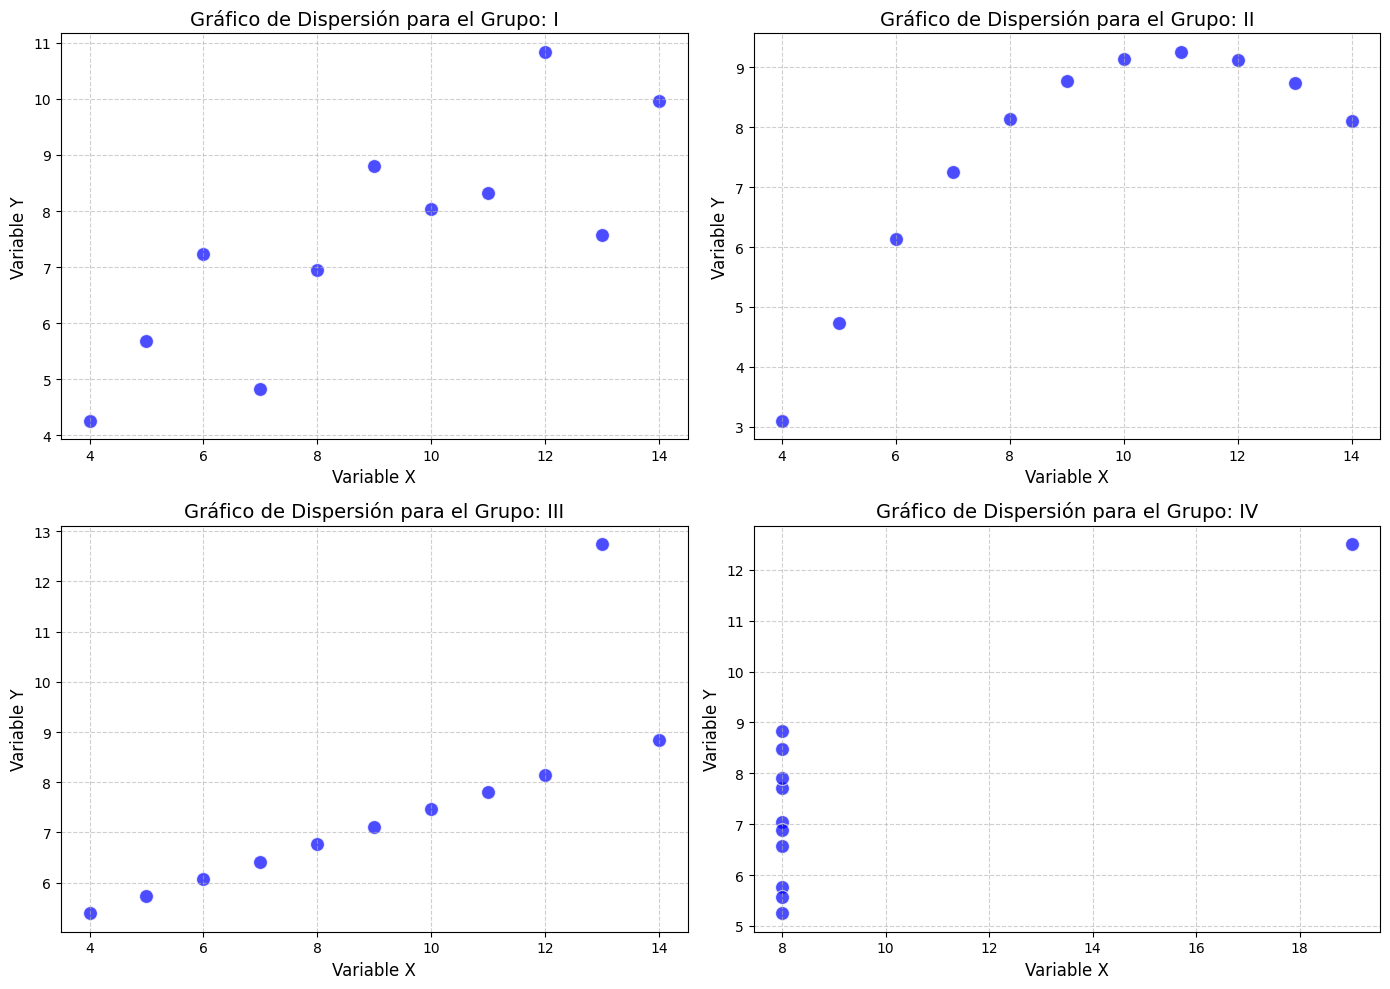

In [8]:
unique_datasets = data['dataset'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, dataset_name in enumerate(unique_datasets):
    subset = data[data['dataset'] == dataset_name]
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i], s=100, color='blue', alpha=0.7)
    axes[i].set_title(f'Gráfico de Dispersión para el Grupo: {dataset_name}', fontsize=14)
    axes[i].set_xlabel('Variable X', fontsize=12)
    axes[i].set_ylabel('Variable Y', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [9]:
for dataset_name in unique_datasets:
    subset = data[data['dataset'] == dataset_name]
    print(f'\nEstadísticas descriptivas para el Grupo: {dataset_name}')
    print(subset.describe())



Estadísticas descriptivas para el Grupo: I
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031568
min     4.000000   4.260000
25%     6.500000   6.315000
50%     9.000000   7.580000
75%    11.500000   8.570000
max    14.000000  10.840000

Estadísticas descriptivas para el Grupo: II
               x          y
count  11.000000  11.000000
mean    9.000000   7.500909
std     3.316625   2.031657
min     4.000000   3.100000
25%     6.500000   6.695000
50%     9.000000   8.140000
75%    11.500000   8.950000
max    14.000000   9.260000

Estadísticas descriptivas para el Grupo: III
               x          y
count  11.000000  11.000000
mean    9.000000   7.500000
std     3.316625   2.030424
min     4.000000   5.390000
25%     6.500000   6.250000
50%     9.000000   7.110000
75%    11.500000   7.980000
max    14.000000  12.740000

Estadísticas descriptivas para el Grupo: IV
               x          y
count  11.000000  11.000000
mean    

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.




Resultados de la Regresión Lineal para el Grupo: I
  Coeficiente (pendiente): 0.5001
  Intercepción: 3.0001
  Error Cuadrático Medio (MSE): 1.2512
  Coeficiente de Determinación (R²): 0.6665

Resultados de la Regresión Lineal para el Grupo: II
  Coeficiente (pendiente): 0.5000
  Intercepción: 3.0009
  Error Cuadrático Medio (MSE): 1.2524
  Coeficiente de Determinación (R²): 0.6662

Resultados de la Regresión Lineal para el Grupo: III
  Coeficiente (pendiente): 0.4997
  Intercepción: 3.0025
  Error Cuadrático Medio (MSE): 1.2506
  Coeficiente de Determinación (R²): 0.6663

Resultados de la Regresión Lineal para el Grupo: IV
  Coeficiente (pendiente): 0.4999
  Intercepción: 3.0017
  Error Cuadrático Medio (MSE): 1.2493
  Coeficiente de Determinación (R²): 0.6667


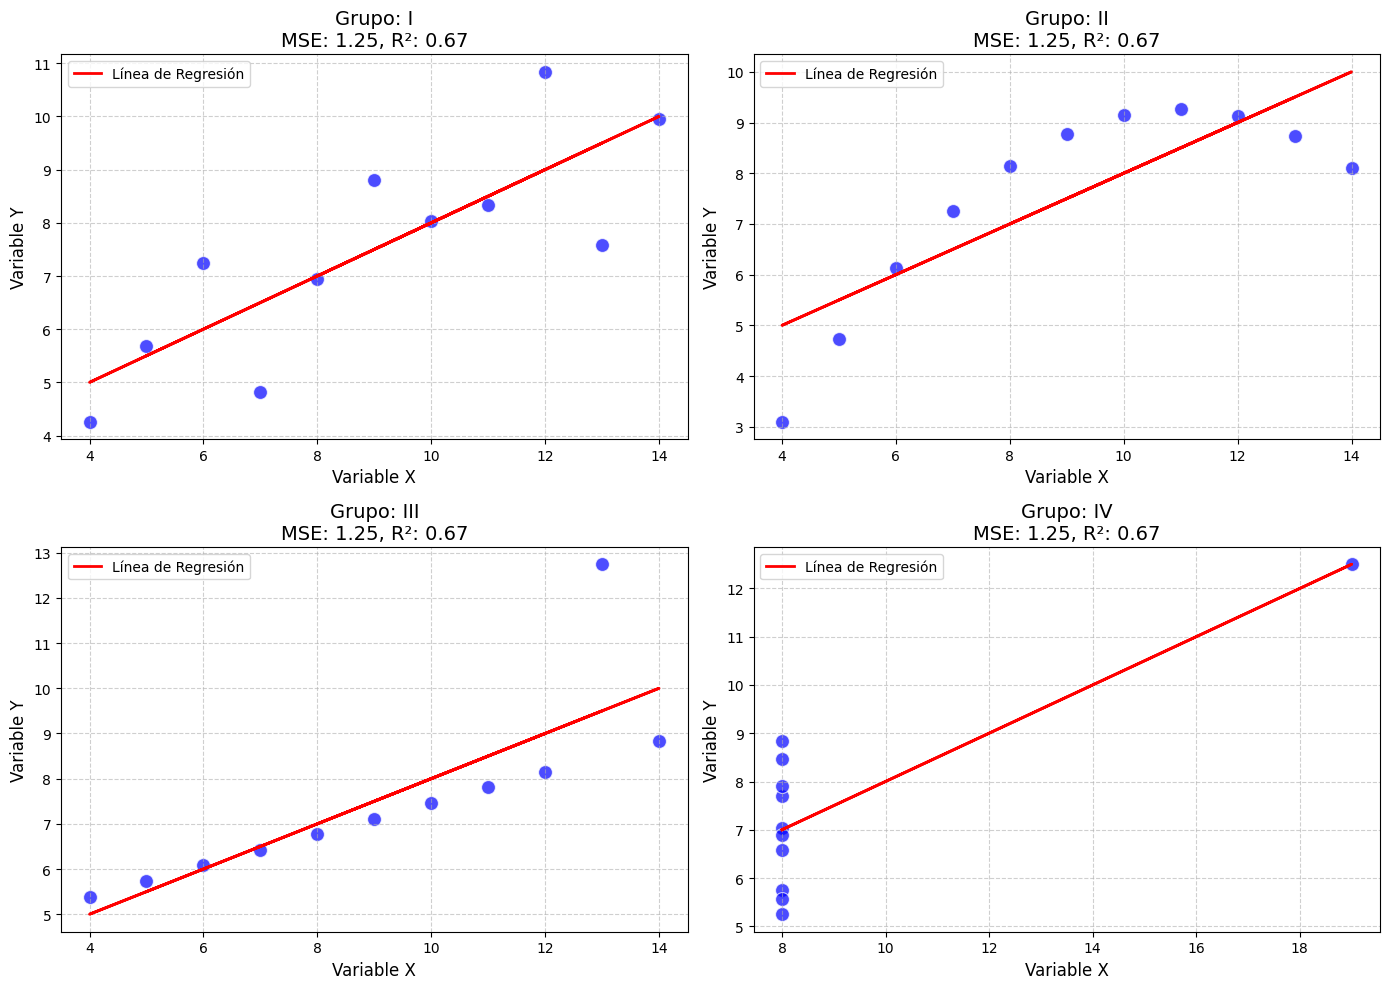

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, dataset_name in enumerate(unique_datasets):
    subset = data[data['dataset'] == dataset_name]
    X = subset[['x']]
    y = subset['y']

    # Crear y entrenar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)

    # Realizar predicciones
    y_pred = model.predict(X)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Imprimir resultados
    print(f'\nResultados de la Regresión Lineal para el Grupo: {dataset_name}')
    print(f'  Coeficiente (pendiente): {model.coef_[0]:.4f}')
    print(f'  Intercepción: {model.intercept_:.4f}')
    print(f'  Error Cuadrático Medio (MSE): {mse:.4f}')
    print(f'  Coeficiente de Determinación (R²): {r2:.4f}')

    # Graficar los resultados
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i], s=100, color='blue', alpha=0.7)
    axes[i].plot(X, y_pred, color='red', linewidth=2, label='Línea de Regresión')
    axes[i].set_title(f'Grupo: {dataset_name}\nMSE: {mse:.2f}, R²: {r2:.2f}', fontsize=14)
    axes[i].set_xlabel('Variable X', fontsize=12)
    axes[i].set_ylabel('Variable Y', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend()

plt.tight_layout()
plt.show()

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.


--- Estrategias de Mejora para el Grupo: I ---
  MSE Mejorado: 1.2512
  R² Mejorado: 0.6665

--- Estrategias de Mejora para el Grupo: II ---
  MSE Mejorado: 0.0000
  R² Mejorado: 1.0000

--- Estrategias de Mejora para el Grupo: III ---
  MSE Mejorado: 1.6376
  R² Mejorado: 0.5630

--- Estrategias de Mejora para el Grupo: IV ---
  MSE Mejorado: 3.9983
  R² Mejorado: -0.0667


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


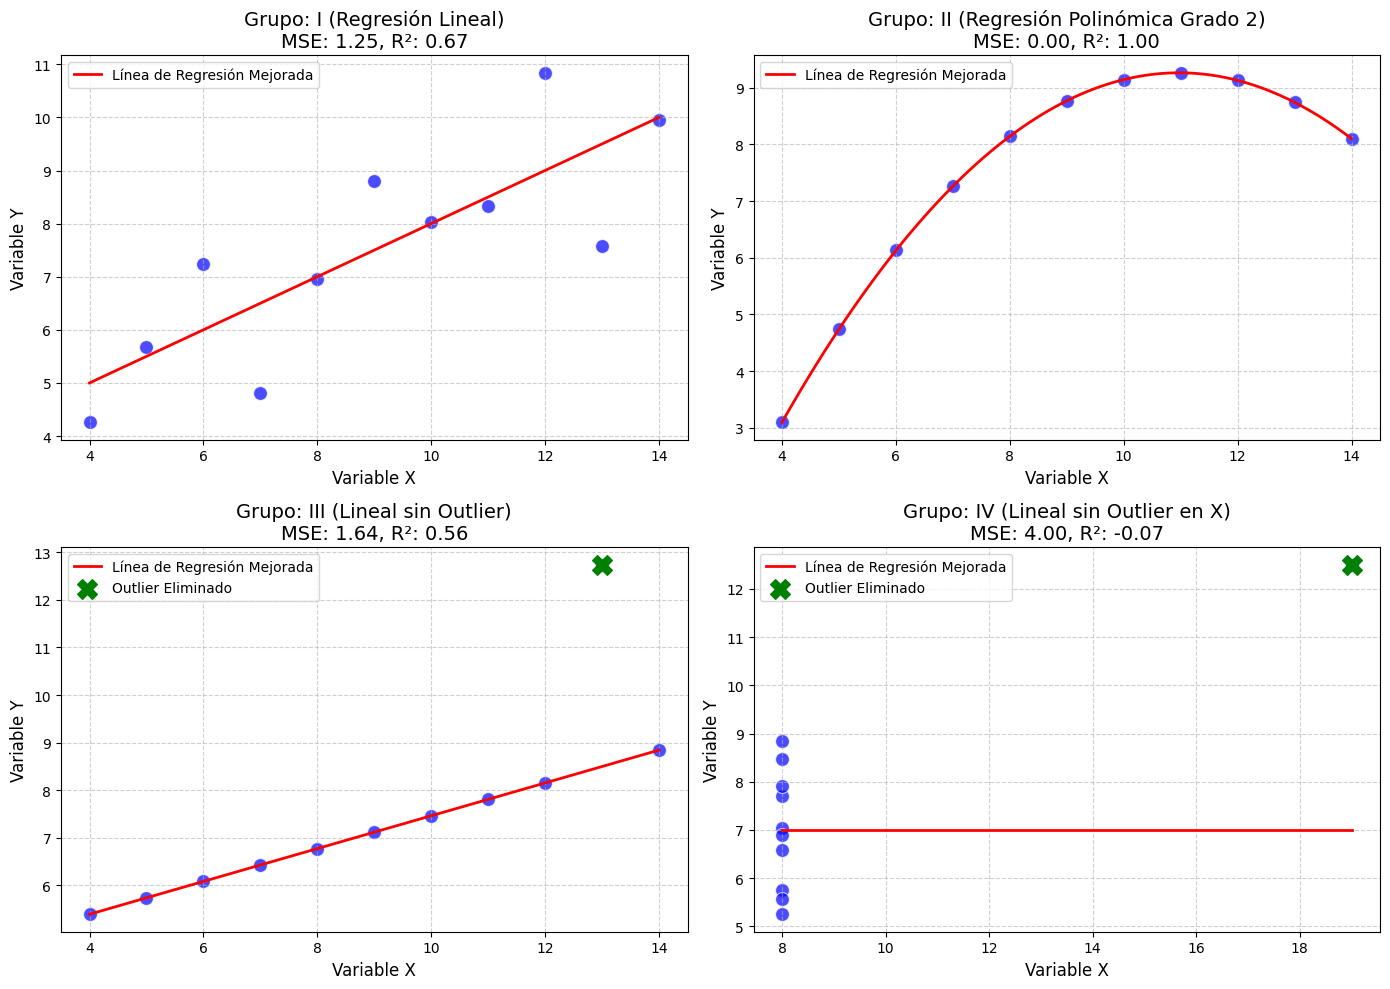

In [12]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, dataset_name in enumerate(unique_datasets):
    subset = data[data['dataset'] == dataset_name]
    X_orig = subset[['x']]
    y_orig = subset['y']

    print(f'\n--- Estrategias de Mejora para el Grupo: {dataset_name} ---')

    if dataset_name == 'I':
        # Para el Grupo I, el modelo lineal ya es adecuado.
        model = LinearRegression()
        model.fit(X_orig, y_orig)
        y_pred = model.predict(X_orig)
        mse = mean_squared_error(y_orig, y_pred)
        r2 = r2_score(y_orig, y_pred)
        title_suffix = ' (Regresión Lineal)'

    elif dataset_name == 'II':
        # Para el Grupo II, usar Regresión Polinómica (grado 2).
        model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
        model.fit(X_orig, y_orig)
        y_pred = model.predict(X_orig)
        mse = mean_squared_error(y_orig, y_pred)
        r2 = r2_score(y_orig, y_pred)
        title_suffix = ' (Regresión Polinómica Grado 2)'

    elif dataset_name == 'III':
        # Para el Grupo III, eliminar el outlier y reajustar la regresión lineal.
        # El outlier es claramente visible en el scatter plot (x=13, y=12.74).
        cleaned_subset = subset[subset['y'] < 12]
        X_cleaned = cleaned_subset[['x']]
        y_cleaned = cleaned_subset['y']

        model = LinearRegression()
        model.fit(X_cleaned, y_cleaned)
        y_pred = model.predict(X_orig) # Predecir sobre X_orig para ver la línea completa
        mse = mean_squared_error(y_orig, model.predict(X_orig)) # Evaluar contra el original
        r2 = r2_score(y_orig, model.predict(X_orig))
        title_suffix = ' (Lineal sin Outlier)'

    elif dataset_name == 'IV':
        # Para el Grupo IV, eliminar el outlier en 'x' y reajustar la regresión lineal.
        # El outlier es claramente (x=19, y=12.50).
        cleaned_subset = subset[subset['x'] < 19]
        X_cleaned = cleaned_subset[['x']]
        y_cleaned = cleaned_subset['y']

        model = LinearRegression()
        model.fit(X_cleaned, y_cleaned)
        y_pred = model.predict(X_orig) # Predecir sobre X_orig para ver la línea completa
        mse = mean_squared_error(y_orig, model.predict(X_orig)) # Evaluar contra el original
        r2 = r2_score(y_orig, model.predict(X_orig))
        title_suffix = ' (Lineal sin Outlier en X)'

    # Imprimir resultados mejorados
    print(f'  MSE Mejorado: {mse:.4f}')
    print(f'  R² Mejorado: {r2:.4f}')

    # Graficar los resultados
    sns.scatterplot(x='x', y='y', data=subset, ax=axes[i], s=100, color='blue', alpha=0.7)
    # Asegurarse de que la línea de regresión se extienda por todo el rango de X_orig para visualización
    x_range = np.linspace(X_orig.min(), X_orig.max(), 100).reshape(-1, 1)
    y_pred_plot = model.predict(x_range)
    axes[i].plot(x_range, y_pred_plot, color='red', linewidth=2, label='Línea de Regresión Mejorada')

    if dataset_name == 'III' or dataset_name == 'IV':
        outlier = subset[~subset.index.isin(cleaned_subset.index)]
        if not outlier.empty:
            axes[i].scatter(outlier['x'], outlier['y'], color='green', s=200, marker='X', label='Outlier Eliminado', zorder=5)

    axes[i].set_title(f'Grupo: {dataset_name}{title_suffix}\nMSE: {mse:.2f}, R²: {r2:.2f}', fontsize=14)
    axes[i].set_xlabel('Variable X', fontsize=12)
    axes[i].set_ylabel('Variable Y', fontsize=12)
    axes[i].grid(True, linestyle='--', alpha=0.6)
    axes[i].legend()

plt.tight_layout()
plt.show()